Enter petal length = 6
Expected sepal length = 6.760


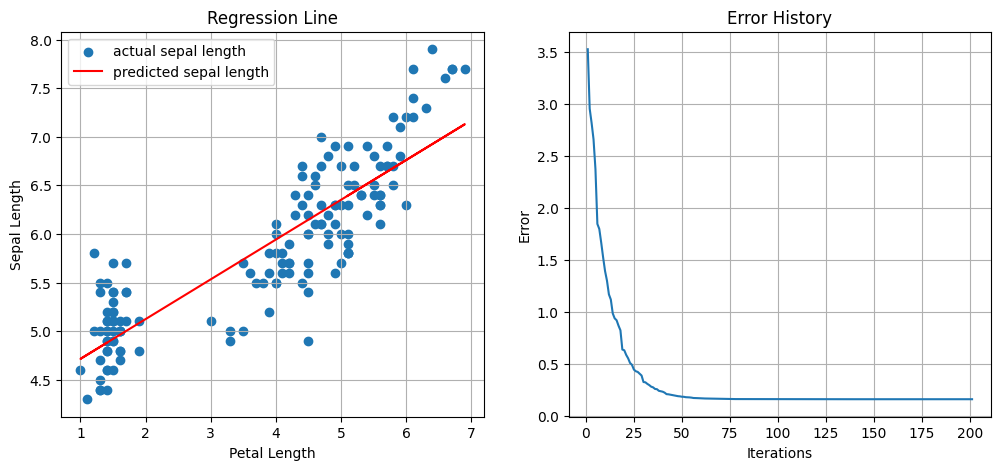

R^2 score = 0.760


In [23]:
from sklearn.datasets import load_iris
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
iris = load_iris()

# For Regression, let's predict Sepal Length (index 0) using Petal Length (index 2)
# We use .reshape(-1, 1) to ensure they are 2D for our matrix math
x_data = iris.data[:, 2]
y_data = iris.data[:, 0]

# Convert x_data to the design matrix 'x' (adding the column of 1s)
x = np.column_stack((x_data, np.ones_like(x_data)))
y = y_data

#Creating the regression model
w = np.array([0,0])
def errorf(w):
  y_predicted = np.dot(x,w)
  error = y - y_predicted
  return(np.mean(error**2))

def gradient_errorf(w):
  y_predicted = np.dot(x,w)
  error = y - y_predicted
  return((-2/len(y_data))*np.dot(x.T,error))

w = np.array([0,0])
rho = 0.5
c1 = 0.1
tol = 0.0001
g = gradient_errorf(w)
it = 0
it_list= []
error_history = []
while np.linalg.norm(g) > tol:
  alpha = 1
  while (errorf(w - (alpha*g))) - errorf(w) > c1*alpha*np.dot(g.T,-g):
    alpha = alpha*rho

  w = w - (alpha*g)
  g = gradient_errorf(w)
  it = it+1
  it_list.append(it)
  error_history.append(errorf(w))

petal_length = int(input('Enter petal length = '))
print(f"Expected sepal length = {w[0] * petal_length + w[1] :.3f}")

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(x_data,y,label = 'actual sepal length ')
plt.plot(x_data, w[0]*x_data + w[1], color='red',label = 'predicted sepal length')
plt.xlabel('Petal Length')
plt.ylabel('Sepal Length')
plt.title('Regression Line')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(it_list,error_history)
plt.xlabel('Iterations')
plt.ylabel('Error')
plt.title('Error History')
plt.grid(True)
plt.show()

#Evaluation

SSres = np.sum((y - np.dot(x,w))**2)
SStot = np.sum((y - np.mean(y))**2)

r_2 = 1 - (SSres/SStot)
print(f"R^2 score = {r_2:.3f}")



